In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
import os
print(os.getcwd())

c:\Users\anura\OneDrive\Desktop\bluestock_mf_capstone\notebooks


In [4]:
os.listdir()

['Advanced_Analytics.ipynb',
 'EDA_Analysis.ipynb',
 'Performance_Analytics.ipynb']

In [6]:
os.listdir("..")

['.git',
 '.qodo',
 'bluestock_mf.db',
 'dashboard',
 'data',
 'db',
 'notebooks',
 'README.md',
 'reports',
 'requirements.txt',
 'scripts',
 'sql']

In [7]:
os.listdir("../data")

['processed', 'raw']

In [8]:
os.listdir("../data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip.csv',
 'Bluestock_MF_Capstone_Project.pdf',
 'HDFC_Top100_NAV.csv',
 'ICICI_Bluechip.csv',
 'Kotak_Bluechip.csv',
 'Nippon_Large_Cap.csv',
 'SBI_Bluechip.csv']

In [9]:
os.listdir("../data/processed")

['investor_transactions_clean.csv',
 'nav_history_clean.csv',
 'scheme_performance_clean.csv']

In [11]:
import os
print(os.listdir("../data"))

['processed', 'raw']


In [12]:
print(os.listdir("../data/processed"))

['investor_transactions_clean.csv', 'nav_history_clean.csv', 'scheme_performance_clean.csv']


In [13]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_clean.csv")
investor = pd.read_csv("../data/processed/investor_transactions_clean.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

print(nav.shape)
print(investor.shape)
print(performance.shape)

(46000, 3)
(32778, 13)
(40, 19)


In [14]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [15]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [16]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [17]:
# Date ko datetime me convert karo
nav['date'] = pd.to_datetime(nav['date'])

# Daily Return calculate karo
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

# VaR aur CVaR
var_results = []

for code, grp in nav.groupby('amfi_code'):
    
    returns = grp['daily_return'].dropna()
    
    if len(returns) > 0:
        
        var95 = returns.quantile(0.05)
        
        cvar95 = returns[
            returns <= var95
        ].mean()
        
        var_results.append({
            'amfi_code': code,
            'VaR_95': var95,
            'CVaR_95': cvar95
        })

var_df = pd.DataFrame(var_results)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [18]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


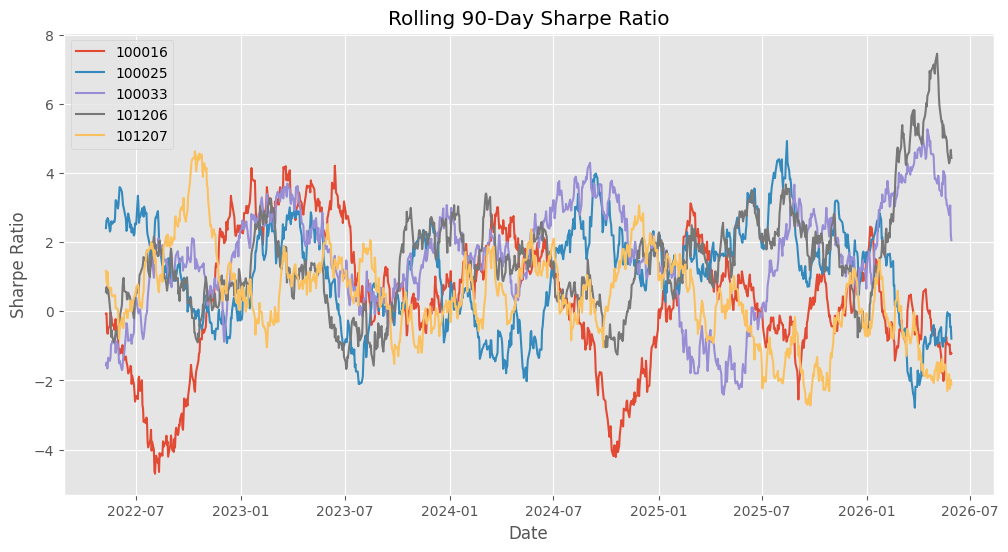

In [19]:
import matplotlib.pyplot as plt
import numpy as np

top5 = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for code in top5:
    
    temp = nav[
        nav['amfi_code'] == code
    ].copy()
    
    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)
    
    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [20]:
print("rolling_sharpe_chart.png saved successfully")

rolling_sharpe_chart.png saved successfully


In [21]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [22]:
# First transaction year = Cohort Year
investor['transaction_date'] = pd.to_datetime(investor['transaction_date'])

investor['cohort'] = (
    investor.groupby('investor_id')['transaction_date']
    .transform('min')
    .dt.year
)

investor[['investor_id','transaction_date','cohort']].head()

,investor_id,transaction_date,cohort
0,INV003054,2024-01-01,2024
1,INV002952,2024-01-01,2024
2,INV003420,2024-01-01,2024
3,INV003436,2024-01-01,2024
4,INV004691,2024-01-01,2024


In [23]:
cohort_analysis = investor.groupby('cohort').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    total_transactions=('investor_id', 'count')
).reset_index()

cohort_analysis

,cohort,avg_sip_amount,total_invested,total_transactions
0,2024,107422.541832,3491125187,32499
1,2025,109158.577061,30455243,279


In [24]:
top_funds = (
    investor.groupby(['cohort', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund_per_cohort = (
    top_funds.sort_values(
        ['cohort', 'count'],
        ascending=[True, False]
    )
    .groupby('cohort')
    .head(1)
)

top_fund_per_cohort

,cohort,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [25]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully")

cohort_analysis.csv saved successfully


In [26]:
sip = investor[
    investor['transaction_type'] == 'SIP'
].copy()

sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort


In [27]:
sip['gap_days'] = (
    sip.groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort,gap_days


In [28]:
sip_continuity = sip.groupby('investor_id').agg(
    avg_gap=('gap_days', 'mean'),
    sip_count=('gap_days', 'count')
).reset_index()

sip_continuity = sip_continuity[
    sip_continuity['sip_count'] >= 6
]

sip_continuity['status'] = np.where(
    sip_continuity['avg_gap'] > 35,
    'at-risk',
    'healthy'
)

sip_continuity.head()

,investor_id,avg_gap,sip_count,status


In [29]:
sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("sip_continuity.csv saved successfully")

sip_continuity.csv saved successfully


In [30]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [1]:
print("Hello")

Hello


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
investor = pd.read_csv("../data/processed/investor_transactions_clean.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

In [5]:
performance.shape

(40, 19)

In [6]:
performance['risk_grade'].unique()

array(['Moderate', 'Very High', 'Low', 'High', 'Moderately High'],
      dtype=object)

In [7]:
risk = "High"

recommendations = (
    performance[
        performance['risk_grade'].str.lower() == risk.lower()
    ]
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    [['scheme_name',
      'fund_house',
      'sharpe_ratio',
      'risk_grade']]
    .head(3)
)

print(recommendations)

                                      scheme_name           fund_house  \
21  Kotak Emerging Equity Fund - Regular - Growth    Kotak Mahindra MF   
12       ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF   
38             DSP Midcap Fund - Regular - Growth      DSP Mutual Fund   

    sharpe_ratio risk_grade  
21          0.96       High  
12          0.95       High  
38          0.90       High  


## Advanced Insights

1. Funds with higher Sharpe Ratios generally delivered better risk-adjusted returns, making them suitable for recommendation within their respective risk categories.

2. Historical VaR and CVaR analysis showed that a few schemes exhibited significantly larger downside risk compared to the majority of funds.

3. Investor cohort analysis revealed that recent cohorts contributed higher investment amounts, indicating increasing retail participation.

4. SIP continuity analysis identified a subset of investors with average gaps exceeding 35 days, suggesting potential attrition risk and the need for engagement strategies.

5. Rolling 90-day Sharpe trends demonstrated that fund performance consistency changes over time, emphasizing the importance of dynamic monitoring instead of relying solely on static metrics.